# Rashevsky (1937): An Early Dynamical Model of Conditioning

This notebook accompanies **N. Rashevsky, "Mathematical Biophysics of Conditioning" (1937)**  [link](https://link.springer.com/article/10.1007/BF02288396)

The goal is **not** to study a modern trainable neural network, but to explore one of the earliest attempts to study a biological and psychological phenomenon using mathematics and physics.

More specifically, Rashevsky's broader project was to understand biological ideas such as neural activity, behavior, and conditioning through simplified biophysical assumptions expressed as equations. In this paper, he asks whether **conditioning** can be understood as the dynamics of a small neural circuit rather than as a mysterious special mechanism.

To do that, Rashevsky proposes a mathematical model with:
- **thresholds**
- **saturation**
- **excitation and inhibition**
- **recurrent feedback**
- **memory through persistent activity**

The central idea is that **conditioning** can be explained as a change of state in a recurrent neural circuit, rather than as a special extra "conditioning mechanism". In the paper, Rashevsky explicitly argues that conditioning should be understood as a case of **physical hysteresis**.

A hysteretic system has a form of **memory**: the current state is not determined only by the current input, but also by the system's past. In Rashevsky's model, the same present stimulus can produce different outcomes depending on whether the recurrent circuit is still in its resting state or has previously been pushed into a self-sustaining excited state. Rashevsky explicitly presents conditioning as a complex case of ordinary physical hysteresis. In simple terms, this means that the current behavior of the system depends not only on its present input, but also on its past state.


## What is conditioning?

In **classical conditioning**, a stimulus that initially does not trigger a response can acquire that ability through repeated association with another stimulus.

Classic example:

- food naturally causes salivation,
- a bell initially does not,
- after repeated pairings of bell + food,
- the bell alone can trigger salivation.

In Rashevsky's setting, the question is:

> **How can a nervous system physically change so that a previously neutral stimulus starts producing a response?**

His proposed answer is: a recurrent excitatory circuit can be pushed into a new persistent state, and that state change can later allow the conditioned stimulus to trigger the response.


## How the model works

The paper builds up the model in stages.

#### 1. A stimulus produces neural excitation
A continuous physiological stimulus produces a **train of impulses**, and Rashevsky defines an excitation intensity ($E$) based on the frequency of those impulses. For moderate input, excitation grows with stimulus strength, but due to refractoriness it cannot grow forever and instead **saturates**.

Intuitively, this means that a stronger stimulus can make the response larger, but only up to a limit: after some point the system cannot keep increasing its activity indefinitely.

#### 2. Excitatory and inhibitory quantities evolve over time
At a synapse or fiber ending, Rashevsky introduces:

- an **excitatory quantity** ($e$),
- an **inhibitory quantity** ($j$).

These do not stay constant: they **build up** under stimulation and **decay** over time. In Rashevsky's model, the excitatory and inhibitory factors are governed by

$$
\frac{de}{dt} = AE - ae
$$

and

$$
\frac{dj}{dt} = BE - bj.
$$

Here, $E$ denotes the excitation intensity, $A$ and $B$ control how strongly stimulation produces $e$ and $j$, and $a$ and $b$ determine their decay rates. So when stimulation is present, $e$ and $j$ increase; when stimulation is absent, they relax back toward zero.

#### 3. Neighboring fibers respond only above threshold
A connection only becomes active when excitation is strong enough relative to inhibition. This creates a **thresholded nonlinear system**.

#### 4. Recurrent excitation can create persistent activity
In the central circuit two neurons excite each other. Rashevsky explains that if the initial excitation is too small, activity dies out. But if it is large enough, the two neurons can keep each other active, so that the system remains excited even after the original external input is removed.


## The core recurrent circuit

The most important mathematical object in the paper is the **two-neuron recurrent loop**.

<div>
<center>
    <img src="excitation loop.svg" width="300"/>
</center>
</div>

Rashevsky considers two neurons (or fibers), denoted $I$ and $II$, arranged so that each excites the other. Writing the excitation intensities as \(E_1\) and \(E_2\), he first obtains

$$
\begin{aligned}
E_1 &= \frac{I_1}{\theta_1}\left[1 - e^{-a_1 \theta_1 (e_1 - h_1)}\right], \\
E_2 &= \frac{I_2}{\theta_2}\left[1 - e^{-a_2 \theta_2 (e_2 - h_2)}\right].
\end{aligned}
$$

Substituting these into the excitatory dynamics gives the coupled nonlinear system

$$
\begin{aligned}
\frac{de_1}{dt} &= \frac{A I_2}{\theta_2}\left[1 - e^{-a_2 \theta_2 (e_2 - h_2)}\right] - a e_1, \\
\frac{de_2}{dt} &= \frac{A I_1}{\theta_1}\left[1 - e^{-a_1 \theta_1 (e_1 - h_1)}\right] - a e_2.
\end{aligned}
$$

These are the core equations of the recurrent circuit. The state of each neuron decays over time, but is also driven by the saturating nonlinear excitation produced by the other neuron. Rashevsky notes that this nonlinear system does not have a known analytic solution, and therefore studies it graphically. This is exactly why numerical simulation is a natural modern way to study the model.

## Reflection — Rashevsky and modern neural networks

This model is historically interesting because it shares some structural ideas with modern neural networks, but it is also very different in purpose and method.

**Question.** Give at least three similarities and/or three differences (clearly indicate which is which) between Rashevsky's model and modern neural networks.

<div style="border: 2px solid #c97a00; background-color: #fff4db; padding: 12px; border-radius: 8px;">
<strong>&lt;ANSWER HERE&gt;</strong>
</div>


## Two qualitative regimes

The goal of this notebook is to reproduce the two main qualitative behaviors of Rashevsky's two-neuron recurrent circuit.

To understand the figures in the paper, it helps to read them as **phase-plane diagrams**. A point in the plane represents the current state of the system, namely the pair $(e_1, e_2)$. The two special curves indicate where one of the time-derivatives becomes zero:
- on one curve, $\frac{de_1}{dt} = 0$;
- on the other curve, $\frac{de_2}{dt} = 0$.

These curves divide the plane into regions in which $e_1$ and $e_2$ either increase or decrease. The arrows then show how the state $(e_1,e_2)$ moves over time.

The key question is: **where do trajectories end up?**

<center>
<table><tr>
<td> <img src="figure_2.png" alt="Regime 1" style="width: 400px;"/> </td>
<td> <img src="figure_3.png" alt="Regime 2" style="width: 400px;"/> </td>
</tr></table>
</center>


### Regime 1: persistent activity

In one parameter regime, the two zero-derivative curves intersect at two nonzero points. Rashevsky argues that one of these is **unstable**, while the other is **stable**. Together with the resting state $(0,0)$, this means the system has two stable outcomes:
- the quiescent state $(e_1,e_2)=(0,0)$,
- a nonzero self-sustaining active state.

A boundary separates the two behaviors: if the system is pushed far enough, it crosses that boundary and then evolves toward the active equilibrium. In Rashevsky's words, the system "tips over" into the nonzero state and remains there even after the external disturbance is removed.

This is the regime that gives the circuit a form of memory.

### Regime 2: no self-sustaining activity

In the second parameter regime, the geometry changes. The system no longer has a stable nonzero equilibrium. Rashevsky states that in this case, in the absence of external stimulation, the **only stable state** is the resting state $(e_1,e_2)=(0,0)$.

So here the recurrent excitation is not strong enough to sustain itself: activity may rise temporarily, but it eventually dies out.

### Why this matters

This is why the model is interesting computationally. By simulating the same differential equations for different parameter values, we can recover two qualitatively different behaviors:
1. a circuit with a self-sustaining active state,
2. a circuit whose activity always decays back to zero.

In the paper, Rashevsky explicitly says that whether we obtain the first or the second case depends on the numerical values of the constants in the equations.

## From paper to computation

We will use a simple symmetric version of the Figure 1 model.

Let:

- `e1(t)` be the excitatory state associated with neuron 1,
- `e2(t)` be the excitatory state associated with neuron 2.

Each state:

- **decays** over time,
- is **driven** by the other neuron's excitation,
- uses a **thresholded saturating nonlinearity**.

A convenient implementation is:

$$
\dot e_1 = A \, E(e_2; \alpha, h_2) - e_1,
\qquad
\dot e_2 = A \, E(e_1; \alpha, h_1) - e_2,
$$

where

$$
E(x; \alpha, h)=
\begin{cases}
1-e^{-\alpha(x-h)}, & x>h \\
0, & x\le h.
\end{cases}
$$

This captures the key qualitative ingredients from the paper:

- no activation below threshold,
- increasing activation above threshold,
- saturation for large activation,
- recurrent amplification through the other unit.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Exercise 1 — Implement the saturating excitation function

**Task.** Implement a thresholded saturating nonlinearity `excitation(x, alpha, h)`.

Requirements:

- return `0` when `x <= h`,
- otherwise return the saturating expression above,
- support both scalars and NumPy arrays.

### Solution


In [57]:

def excitation(x, alpha, h):
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    mask = x > h
    y[mask] = 1.0 - np.exp(-alpha * (x[mask] - h))

    # return a scalar if the input was scalar
    if y.ndim == 0:
        return float(y)
    return y


Let's quickly inspect the shape of this nonlinearity.


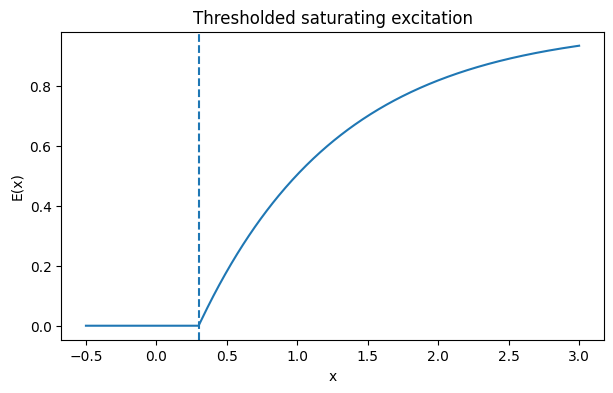

In [58]:

x = np.linspace(-0.5, 3.0, 500)
y = excitation(x, alpha=1.0, h=0.3)

plt.figure(figsize=(7, 4))
plt.plot(x, y)
plt.axvline(0.3, linestyle="--")
plt.xlabel("x")
plt.ylabel("E(x)")
plt.title("Thresholded saturating excitation")
plt.show()


## Exercise 2 — Implement the 2-neuron recurrent loop

**Task.** Implement the ODE system for the excitatory loop. The `rashevsky_rhs` function takes as input a state $(e_1, e_2)$, t, and params. Use a parameter dictionary with the following keys:
- `A`
- `alpha`
- `h1`, `h2`

Pseudocode:
1. Compute the excitation of $e_1$ and $e_2$ as $E_1$ and $E_2$.
2. Return a tuple of $[de1dt, de2dt]$ which can be computed as:
$$
\frac{de_1}{dt} = AE_1 - e_1
$$

and

$$
\frac{de_2}{dt} = AE_2 - e_2.
$$

### Solution


In [59]:

def rashevsky_rhs(state, t, params):
    e1, e2 = state

    E1 = excitation(e1, alpha=params["alpha"], h=params["h1"])
    E2 = excitation(e2, alpha=params["alpha"], h=params["h2"])

    de1dt = params["A"] * E2 - e1
    de2dt = params["A"] * E1 - e2
    return [de1dt, de2dt]


We also define a helper to simulate the system.


In [ ]:

def simulate_rashevsky(x0, t, params):
    return odeint(rashevsky_rhs, x0, t, args=(params,))

## Exercise 3 — Run a first simulation

When you make the first plot, look for the main qualitative question: does the activity die out, or does it settle to a nonzero level?

**Task.** Choose a parameter setting and initial condition, simulate the system, and plot `e1(t)` and `e2(t)`.

### Solution


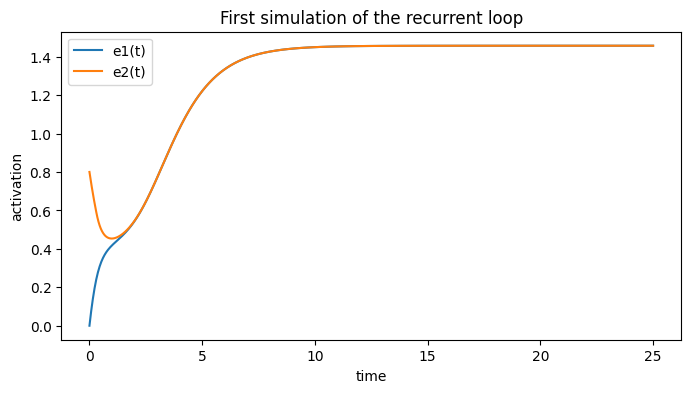

In [73]:

params_base = {
    "A": 1.6,
    "alpha": 2.0,
    "h1": 0.25, "h2": 0.25,
}

t = np.linspace(0, 25, 1000)
x0 = [0.0, 0.8]

sol = simulate_rashevsky(x0, t, params_base)

plt.figure(figsize=(8, 4))
plt.plot(t, sol[:, 0], label="e1(t)")
plt.plot(t, sol[:, 1], label="e2(t)")
plt.xlabel("time")
plt.ylabel("activation")
plt.title("First simulation of the recurrent loop")
plt.legend()
plt.show()


## Exercise 4 — Study sensitivity to the initial condition

A central theme in the paper is that the same system can behave differently depending on whether the initial perturbation is strong enough to cross a threshold.

**Task.** Simulate the same parameter setting for several initial conditions and compare trajectories.

### Solution


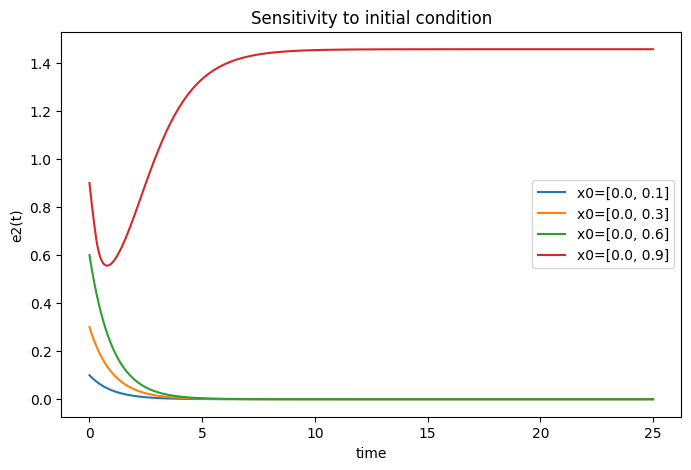

In [62]:

initial_conditions = [
    [0.0, 0.1],
    [0.0, 0.3],
    [0.0, 0.6],
    [0.0, 0.9],
]

plt.figure(figsize=(8, 5))
for x0 in initial_conditions:
    sol = simulate_rashevsky(x0, t, params_base)
    label = f"x0={x0}"
    plt.plot(t, sol[:, 1], label=label)

plt.xlabel("time")
plt.ylabel("e2(t)")
plt.title("Sensitivity to initial condition")
plt.legend()
plt.show()


### Interpretation

When the initial perturbation is too small, activity may decay back to zero.  
When it is large enough, recurrent amplification can sustain a nonzero level of activity.

That is the key hysteresis-like intuition in the paper.


## Exercise 5 — Reproduce two qualitative regimes

The paper discusses two important qualitative cases:

- a regime where the system can sustain nonzero activity,
- a regime where activity always dies out.

We now build two parameter sets:

- `params_persistent`: persistent activity is possible,
- `params_quiescent`: trajectories return to zero.

### Solution


In [ ]:

params_persistent = {
    "A": 1.0,
    "alpha": 4.0,
    "h1": 0.30, "h2": 0.30,
}

params_quiescent = {
    "A": 1.0,
    "alpha": 4.0,
    "h1": 0.50, "h2": 0.50,
}


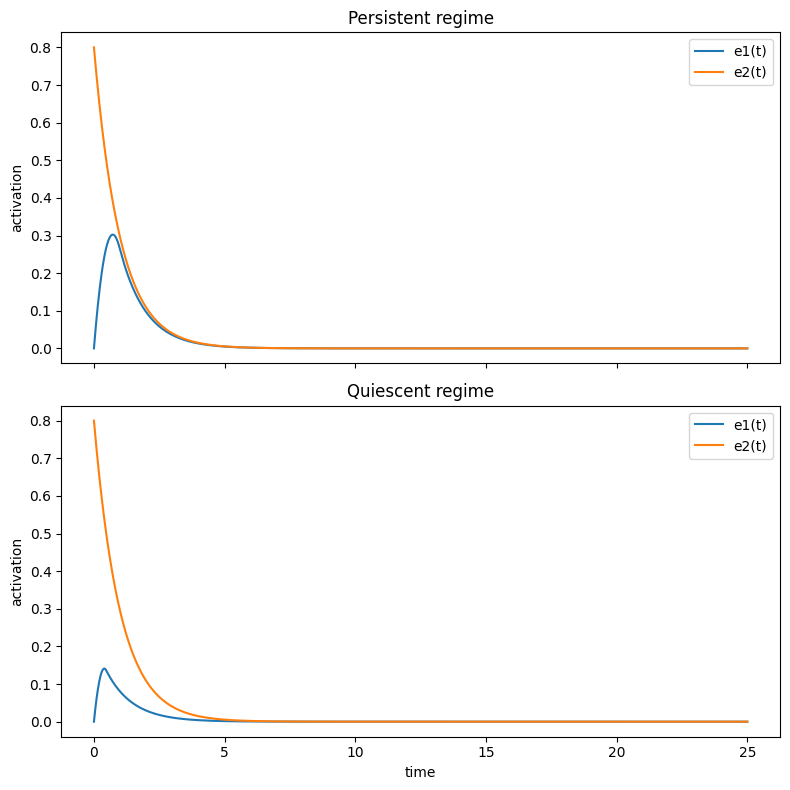

In [64]:

def plot_time_series_comparison(params_list, names, x0=(0.0, 0.8), t=np.linspace(0, 25, 1000)):
    fig, axes = plt.subplots(len(params_list), 1, figsize=(8, 4 * len(params_list)), sharex=True)
    if len(params_list) == 1:
        axes = [axes]

    for ax, params, name in zip(axes, params_list, names):
        sol = simulate_rashevsky(x0, t, params)
        ax.plot(t, sol[:, 0], label="e1(t)")
        ax.plot(t, sol[:, 1], label="e2(t)")
        ax.set_title(name)
        ax.set_ylabel("activation")
        ax.legend()

    axes[-1].set_xlabel("time")
    plt.tight_layout()
    plt.show()

plot_time_series_comparison(
    [params_persistent, params_quiescent],
    ["Persistent regime", "Quiescent regime"],
)


## Exercise 6 — Plot trajectories for many initial conditions

**Task.** For each regime, simulate many initial conditions and compare the long-term behavior.

### Solution


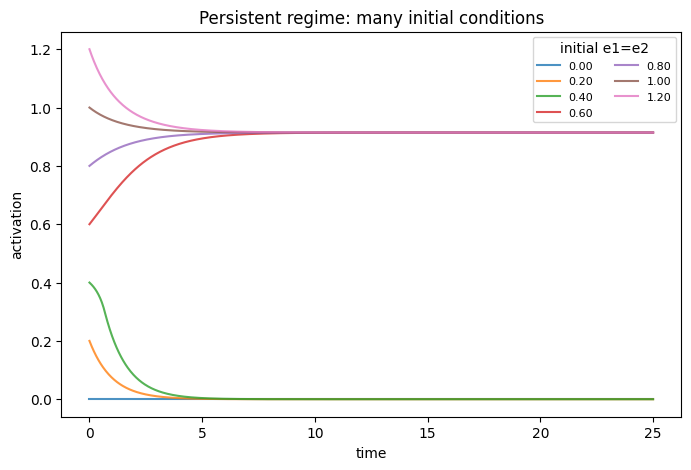

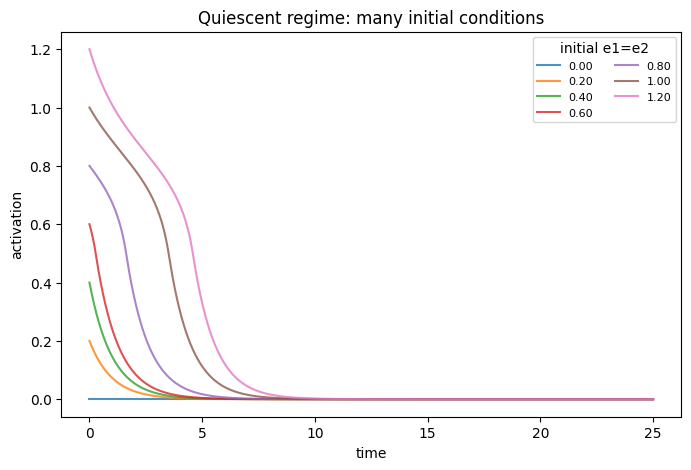

In [65]:

def plot_many_initial_conditions(params, title, grid=np.linspace(0, 1.2, 7), t=np.linspace(0, 25, 1000)):
    plt.figure(figsize=(8, 5))
    for e0 in grid:
        sol = simulate_rashevsky([e0, e0], t, params)
        plt.plot(t, sol[:, 0], alpha=0.8, label=f"{e0:.2f}")

    plt.xlabel("time")
    plt.ylabel("activation")
    plt.title(title)
    plt.legend(title="initial e1=e2", ncol=2, fontsize=8)
    plt.show()

plot_many_initial_conditions(params_persistent, "Persistent regime: many initial conditions")
plot_many_initial_conditions(params_quiescent, "Quiescent regime: many initial conditions")


## Exercise 7 — Explore the phase plane

A good way to understand the model is to inspect trajectories in the `(e1, e2)` plane.

A phase-plane trajectory shows how the pair `(e1, e2)` moves over time. Instead of plotting each variable against time, we plot the state of the whole system against itself.

**Task.** Plot several trajectories in phase space.

### Solution


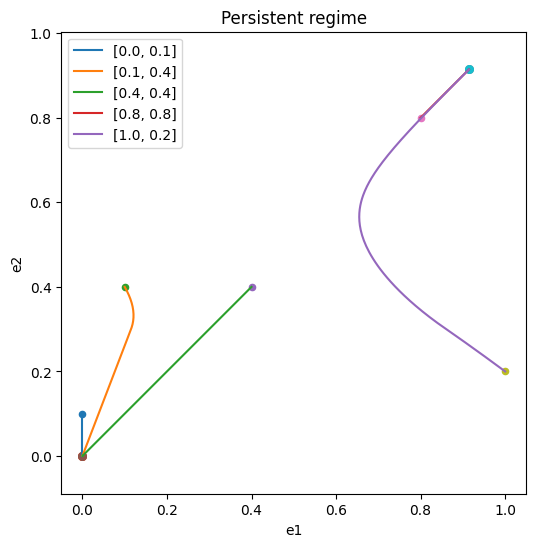

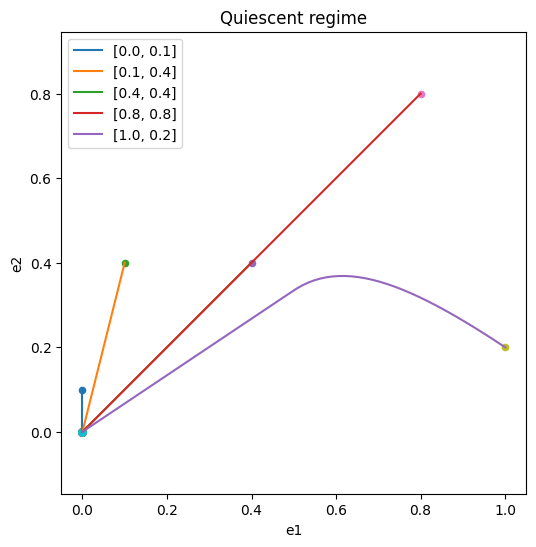

In [66]:

def plot_phase_plane_trajectories(params, initials, t=np.linspace(0, 25, 1000), title="Phase plane trajectories"):
    plt.figure(figsize=(6, 6))
    for x0 in initials:
        sol = simulate_rashevsky(x0, t, params)
        plt.plot(sol[:, 0], sol[:, 1], label=f"{x0}")
        plt.scatter(sol[0, 0], sol[0, 1], s=20)
        plt.scatter(sol[-1, 0], sol[-1, 1], s=30)

    plt.xlabel("e1")
    plt.ylabel("e2")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

initials = [
    [0.0, 0.1],
    [0.1, 0.4],
    [0.4, 0.4],
    [0.8, 0.8],
    [1.0, 0.2],
]

plot_phase_plane_trajectories(params_persistent, initials, title="Persistent regime")
plot_phase_plane_trajectories(params_quiescent, initials, title="Quiescent regime")


## Exercise 9 — Approximate the nullclines

The nullclines are defined by:

- `de1/dt = 0`,
- `de2/dt = 0`.

They help explain why one parameter regime can support persistent activity while another cannot.

**Task.** Approximate the nullclines numerically and plot them.

### Solution


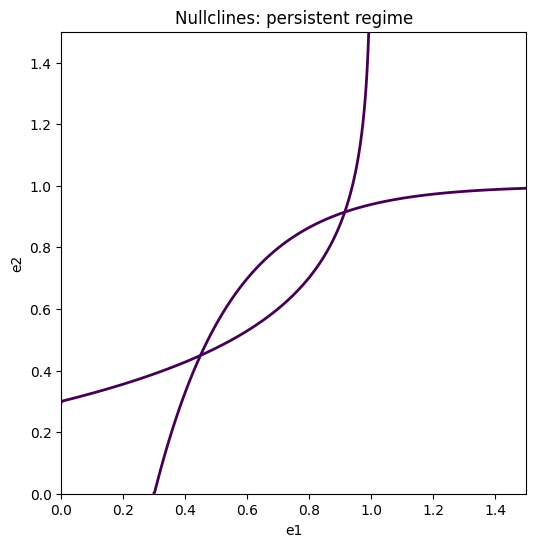

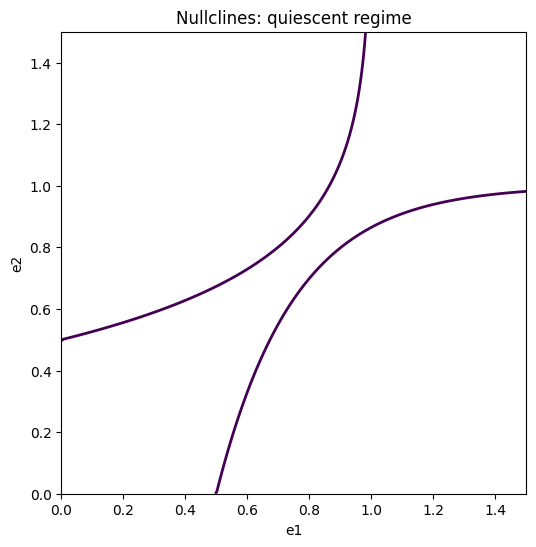

In [67]:

def plot_nullclines(params, e1_range=(0, 1.5), e2_range=(0, 1.5), n=300, title="Nullclines"):
    e1_vals = np.linspace(*e1_range, n)
    e2_vals = np.linspace(*e2_range, n)
    E1g, E2g = np.meshgrid(e1_vals, e2_vals)

    U = np.zeros_like(E1g)
    V = np.zeros_like(E2g)

    for i in range(n):
        for j in range(n):
            de1dt, de2dt = rashevsky_rhs([E1g[i, j], E2g[i, j]], 0, params)
            U[i, j] = de1dt
            V[i, j] = de2dt

    plt.figure(figsize=(6, 6))
    plt.contour(E1g, E2g, U, levels=[0], linewidths=2)
    plt.contour(E1g, E2g, V, levels=[0], linewidths=2)
    plt.xlabel("e1")
    plt.ylabel("e2")
    plt.title(title)
    plt.xlim(e1_range)
    plt.ylim(e2_range)
    plt.show()

plot_nullclines(params_persistent, title="Nullclines: persistent regime")
plot_nullclines(params_quiescent, title="Nullclines: quiescent regime")


### Interpretation

In the persistent regime, the nullclines can intersect at a nonzero point in a way that supports sustained activity.

In the quiescent regime, the geometry tends to direct trajectories back toward zero.


## Exercise 8 — Reproduce Rashevsky's graphical analysis

We now study a simpler, more symmetric version of the model in order to reproduce the kind of graphical analysis shown in the paper.

In this section, we switch to that paper-style formulation:

$$
\dot e_1 = A\left(1-e^{-\alpha\max(0, e_2-h_2)}\right) - e_1,
$$

$$
\dot e_2 = A\left(1-e^{-\alpha\max(0, e_1-h_1)}\right) - e_2.
$$

This keeps the system symmetric:

- one shared amplitude parameter `A`,
- one shared saturation parameter `alpha`,
- thresholds `h1` and `h2`,
- no separate per-neuron parameters.

**Task.** Reproduce a paper-style phase-plane plot with explicit nullcline curves, trajectories started from the boundary of the square, and one highlighted near-threshold trajectory.

### Solution


In [ ]:
def rashevsky_paper_rhs(state, t, params):
    e1, e2 = state
    A = params["A"]
    alpha = params["alpha"]
    h1 = params["h1"]
    h2 = params["h2"]

    de1dt = A * (1.0 - np.exp(-alpha * np.maximum(0.0, e2 - h2))) - e1
    de2dt = A * (1.0 - np.exp(-alpha * np.maximum(0.0, e1 - h1))) - e2
    return [de1dt, de2dt]


def simulate_rashevsky_paper(x0, t, params):
    return odeint(rashevsky_paper_rhs, x0, t, args=(params,))


def plot_rashevsky_paper_phase_portrait(
    params,
    t=np.linspace(0, 10, 1000),
    x_max=1.5,
    highlighted_initial=(0.0, 0.9779547),
):
    x = np.linspace(0, 4, 400)
    A = params["A"]
    alpha = params["alpha"]
    h1 = params["h1"]
    h2 = params["h2"]

    e1_nullcline = A * (1.0 - np.exp(-alpha * np.maximum(0.0, x - h2)))
    e2_nullcline_input = A * (1.0 - np.exp(-alpha * np.maximum(0.0, x - h1)))

    plt.figure(figsize=(7, 7))
    plt.plot(x, e1_nullcline, linewidth=2, label=r"$\dot e_1 = 0$")
    plt.plot(e2_nullcline_input, x, linestyle="--", linewidth=2, label=r"$\dot e_2 = 0$")

    c0 = np.arange(0, x_max + 1e-9, 0.25)

    for e0 in c0:
        for x0 in ([e0, 0.0], [e0, x_max], [0.0, e0], [x_max, e0]):
            sol = simulate_rashevsky_paper(x0, t, params)
            plt.plot(sol[:, 0], sol[:, 1], color="black", alpha=0.55, linewidth=1)

    sol_highlight = simulate_rashevsky_paper(highlighted_initial, t, params)
    plt.plot(
        sol_highlight[:, 0],
        sol_highlight[:, 1],
        linestyle=":",
        linewidth=2.5,
        color="tab:red",
        label=f"highlighted trajectory: {highlighted_initial}",
    )

    plt.xlim(0, x_max)
    plt.ylim(0, x_max)
    plt.xlabel("e1")
    plt.ylabel("e2")
    plt.title("Paper-style phase portrait for the symmetric Rashevsky model")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


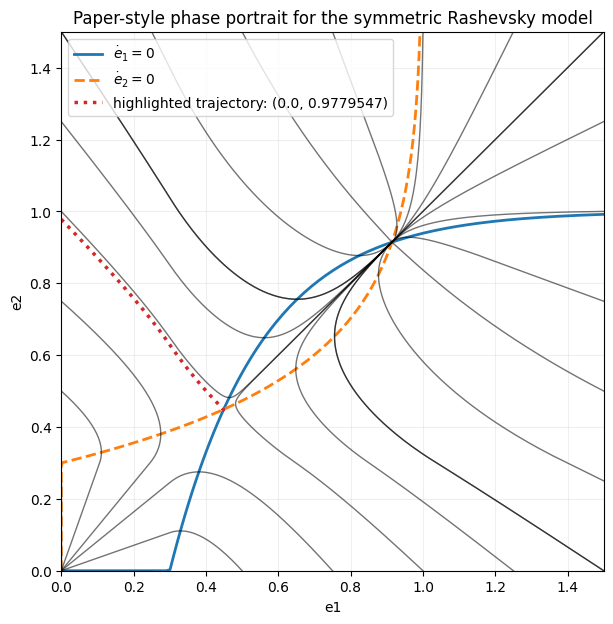

In [69]:
params_paper = {
    "A": 1.0,
    "alpha": 4.0,
    "h1": 0.3,
    "h2": 0.3,
}

plot_rashevsky_paper_phase_portrait(params_paper)


### Exploration questions

1. What happens to the phase portrait if you increase or decrease `A`?
2. How do the nullclines and trajectories change when you raise `h1` and `h2`?
3. For which values of `alpha` does the nonzero active state become easier or harder to sustain?

The main point of this section is to connect the notebook to the graphical style of analysis used in Rashevsky's paper.


## Exercise 10 — Compare the excitatory loop with an inhibitory-style variant

So far, both equations have had the same excitatory form: each neuron drives the other through the same saturating threshold function.

<div>
<center>
    <img src="excitation-inhibiition.svg" width="300"/>
</center>
</div>

For this extension, we now switch to a slightly different notation:

- `a` controls the steepness of the saturating term,
- `alpha` divides the decay term and therefore changes the relaxation timescale,
- `h1` and `h2` are thresholds.

The original mutual-excitation experiment is:

$$
\dot e_1 = \left(1-e^{-a\max(0,e_2-h_2)}\right) - \frac{e_1}{\alpha},
$$

$$
\dot e_2 = \left(1-e^{-a\max(0,e_1-h_1)}\right) - \frac{e_2}{\alpha}.
$$

The inhibitory-style variant keeps the first equation the same, but replaces the second excitatory term by its **complement**:

$$
\dot e_2 = \left(1-\left(1-e^{-a\max(0,e_1-h_1)}\right)\right) - \frac{e_2}{\alpha}.
$$

Conceptually, the first system is a mutual excitatory loop, while the second introduces an opposing or inhibitory-style effect in the second equation.

That difference matters dynamically: in the original system both units reinforce each other, while in the modified system the second unit responds in an opposite or complementary way. This can make the approach to equilibrium more curved, and in some cases more spiral-like.

**Task.** Implement the inhibitory-style variant in this notation.

### Solution


In [70]:

def excitation_r_style(x, a, h):
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)
    mask = x > h
    y[mask] = 1.0 - np.exp(-a * (x[mask] - h))
    if y.ndim == 0:
        return float(y)
    return y


def rashevsky_inhibitory_rhs(state, t, params):
    e1, e2 = state

    E1 = excitation_r_style(e1, a=params["a"], h=params["h1"])
    E2 = excitation_r_style(e2, a=params["a"], h=params["h2"])

    de1dt = E2 - e1 / params["alpha"]
    de2dt = (1.0 - E1) - e2 / params["alpha"]
    return [de1dt, de2dt]


def simulate_inhibitory(x0, t, params):
    return odeint(rashevsky_inhibitory_rhs, x0, t, args=(params,))


## Exercise 11 — Plot the inhibitory-style phase portrait

**Task.** Draw the two nullclines, many trajectories started from the boundary of the square, and one highlighted special trajectory.

This makes it easier to compare the inhibitory-style geometry directly with the earlier paper-style phase-plane analysis.

### Solution


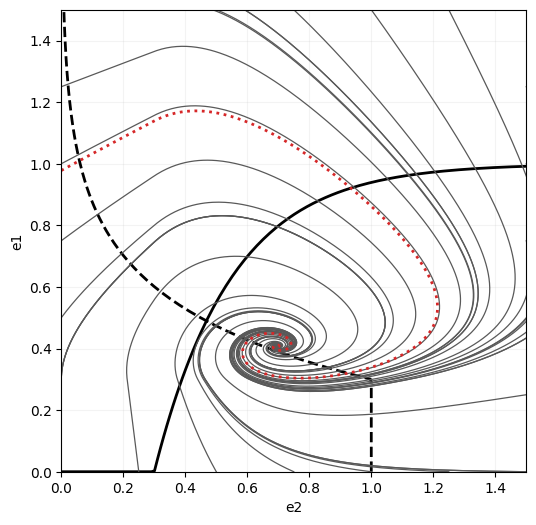

In [71]:

def plot_r_style_inhibitory_phase_portrait(
    params,
    t=np.linspace(0, 40, 4000),
    x_plot_max=1.5,
    x_curve_max=4.0,
    highlighted_initial=(0.0, 0.9779547),
):
    x = np.linspace(0, x_curve_max, 400)
    e1_curve = 1.0 - np.exp(-params["a"] * np.maximum(0.0, x - params["h2"]))
    e2_curve_input = np.exp(-params["a"] * np.maximum(0.0, x - params["h1"]))

    plt.figure(figsize=(6, 6))
    plt.plot(x, e1_curve, linewidth=2, color="black")
    plt.plot(e2_curve_input, x, linestyle="--", linewidth=2, color="black")

    c0 = np.arange(0, x_plot_max + 1e-9, 0.25)
    for e0 in c0:
        for x0 in ([e0, 0.0], [e0, x_plot_max], [0.0, e0], [x_plot_max, e0]):
            sol = simulate_inhibitory(x0, t, params)
            plt.plot(sol[:, 0], sol[:, 1], color="0.35", linewidth=0.9)

    sol_highlight = simulate_inhibitory(highlighted_initial, t, params)
    plt.plot(sol_highlight[:, 0], sol_highlight[:, 1], linestyle=":", linewidth=2, color="tab:red")

    plt.xlim(0, x_plot_max)
    plt.ylim(0, x_plot_max)
    plt.xlabel("e2")
    plt.ylabel("e1")
    plt.grid(alpha=0.15)
    plt.show()


params_inhibitory = {
    "a": 4.0,
    "alpha": 2.0,
    "h1": 0.3,
    "h2": 0.3,
}

plot_r_style_inhibitory_phase_portrait(params_inhibitory)


In this inhibitory-style variant, the second equation no longer reinforces the first in the same way. Instead, it responds to the **complement** of the first excitation term.

That push-pull structure can produce curved trajectories and, for some values of `alpha`, spiral-like approaches to equilibrium. The important point is to observe how the qualitative geometry changes when the coupling becomes asymmetric.


## Exercise 12 — Compare a few values of `alpha`

**Task.** Reproduce the same phase portrait for a few values of the scaling factor `alpha`. In particular, look for more direct settling versus more spiral-like settling.

### Solution


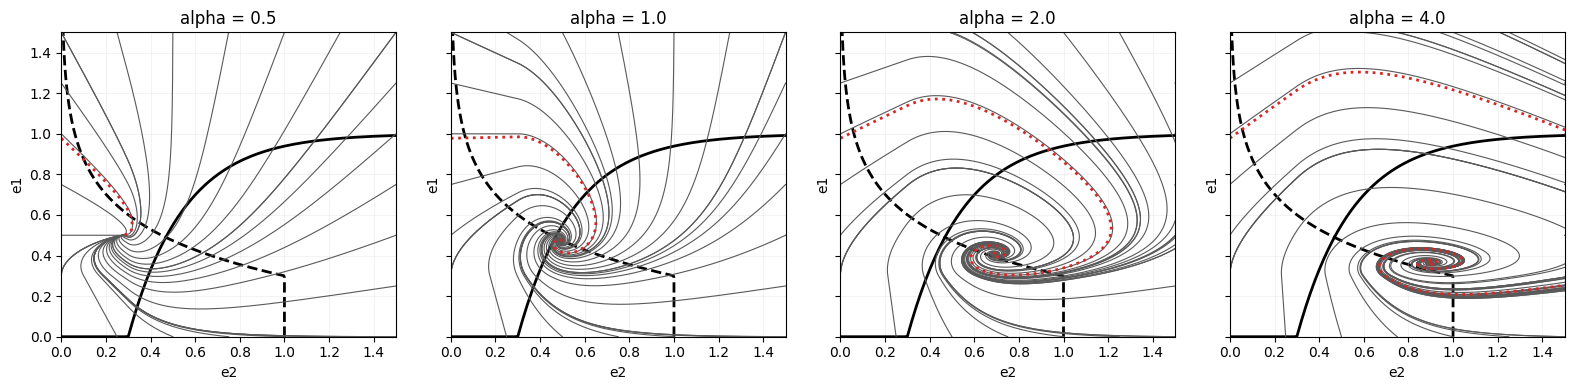

In [72]:

alphas = [0.5, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(1, len(alphas), figsize=(4 * len(alphas), 4), sharey=True)

for ax, alpha in zip(axes, alphas):
    params = params_inhibitory.copy()
    params["alpha"] = alpha

    x = np.linspace(0, 4, 400)
    e1_curve = 1.0 - np.exp(-params["a"] * np.maximum(0.0, x - params["h2"]))
    e2_curve_input = np.exp(-params["a"] * np.maximum(0.0, x - params["h1"]))
    ax.plot(x, e1_curve, linewidth=2, color="black")
    ax.plot(e2_curve_input, x, linestyle="--", linewidth=2, color="black")

    c0 = np.arange(0, 1.5 + 1e-9, 0.25)
    for e0 in c0:
        for x0 in ([e0, 0.0], [e0, 1.5], [0.0, e0], [1.5, e0]):
            sol = simulate_inhibitory(x0, np.linspace(0, 40, 4000), params)
            ax.plot(sol[:, 0], sol[:, 1], color="0.35", linewidth=0.8)

    sol_highlight = simulate_inhibitory([0.0, 0.9779547], np.linspace(0, 40, 4000), params)
    ax.plot(sol_highlight[:, 0], sol_highlight[:, 1], color="tab:red", linestyle=":", linewidth=2)
    ax.set_title(f"alpha = {alpha}")
    ax.set_xlabel("e2")
    ax.set_ylabel("e1")
    ax.set_xlim(0, 1.5)
    ax.set_ylim(0, 1.5)
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()
